In [3]:
#import packages 

import pandas as pd
import matplotlib.pyplot as plt
import scipy as sc
import numpy as np
from scipy.stats import linregress


In [4]:
#reading files 
# combined U-Th Column sediment pteropod data and Me/Ca sediment pteropod data

sedidata = pd.read_excel('UTh and MeCa combined sediment pteropods.xlsx', sheet_name= 'combined sedimentary pteropods',header=1, skiprows=[3, 5, 12]) 
sedidatacsv = "UTh and MeCa combined sediment pteropods.csv"
sedidata.to_csv(sedidatacsv, index=False)
sedidatacsv = pd.read_csv(sedidatacsv)
print(sedidata['Cleaning'])


0         no clean
1         no clean
2       sonic only
3       sonic only
4        sonic+red
5        sonic+red
6        sonic+red
7    sonic++red+ox
8    sonic++red+ox
Name: Cleaning, dtype: object


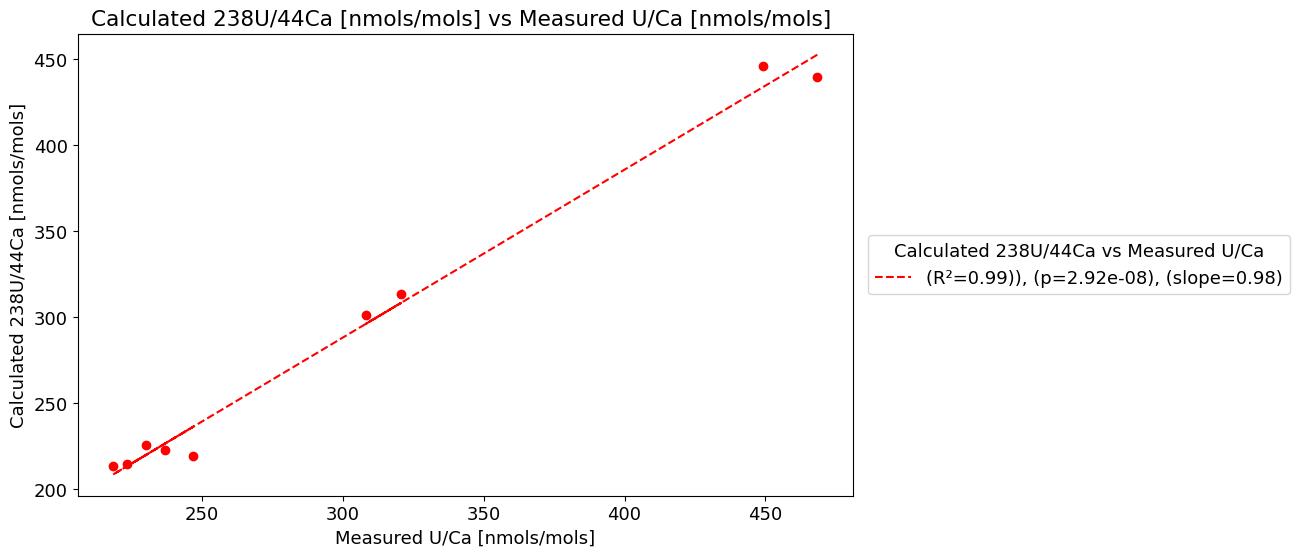

In [5]:
#Graph 1: sedimentary measured U nmols/Ca mols Ratios vs sedimentary columns 238U nmols/44Ca mols calculated

#index data
# measured U nmols/Ca mols from cleaned pteropods (excluding contaminated values)
U_CaMeas = sedidata['U/Ca [nmol/mol]']

#calculated U nmols/Ca mols from column pteropods (excluding contaminated values)
U_CaCalc = sedidata['[238U]nmols/ Ca mol']

# calulate linear regression
slope, intercept, r_value, p_value, std_err = linregress( U_CaMeas, U_CaCalc)
regression_y = slope * U_CaMeas + intercept
r_squared = r_value**2

#create figure
plt.figure(figsize=(10, 6))

#standardize font
plt.rcParams.update({'font.size': 13})

#scatter plot data
plt.scatter(U_CaMeas, U_CaCalc, color = 'r')

#plot linear regression
plt.plot(U_CaMeas, regression_y, label=f'(R²={r_squared:.2f})), (p={p_value:.2e}), (slope={slope:.2f})', color='r', linestyle='--')

# axis labels 
plt.xlabel('Measured U/Ca [nmols/mols]')
plt.ylabel('Calculated 238U/44Ca [nmols/mols]')

#plot title
plt.title('Calculated 238U/44Ca [nmols/mols] vs Measured U/Ca [nmols/mols] ')

#create legend
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', title='Calculated 238U/44Ca vs Measured U/Ca', borderaxespad=0)




7    213.455796
8    225.634111
Name: [238U]nmols/ Ca mol, dtype: float64 4    214.394594
5    222.865186
6    219.164513
Name: [238U]nmols/ Ca mol, dtype: float64


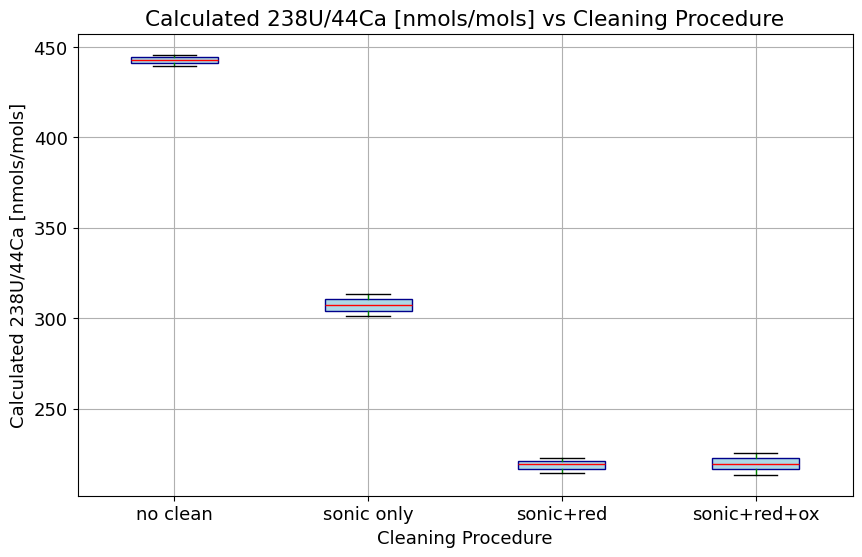

In [6]:
# Graph 2: sedimentary pteropods columns 238U nmols/44Ca mols calculated vs cleaning procedures


#index data by cleaning type
noclean = sedidatacsv[sedidatacsv['Cleaning'].str.contains('no clean')]
sonic = sedidatacsv[sedidatacsv['Cleaning'].str.contains('sonic only')]

#regex gets rid of regex operator of "+"
redsonic = sedidatacsv[sedidatacsv['Cleaning'].str.contains('sonic+red', regex=False)]
oxredsonic = sedidatacsv[sedidatacsv['Cleaning'].str.contains('sonic++red+ox', regex=False)]


# getting U nmols/ Ca mols from each cleaning type 
nocleanU = noclean['[238U]nmols/ Ca mol']
sonicU = sonic['[238U]nmols/ Ca mol']
redsonicU = redsonic['[238U]nmols/ Ca mol']
oxredsonicU = oxredsonic['[238U]nmols/ Ca mol']
print(oxredsonicU, redsonicU)
#combining data
cleantype = nocleanU, sonicU, redsonicU, oxredsonicU
cleaning = {
    'no clean' : nocleanU,
    'sonic only': sonicU,
    'sonic+red' : redsonicU,
    'sonic+red+ox' : oxredsonicU
}
#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantype, tick_labels=cleaning, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))


#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('Calculated 238U/44Ca [nmols/mols]')

#plot title
plt.title('Calculated 238U/44Ca [nmols/mols] vs Cleaning Procedure')

#add grid lines
plt.grid()

1.138403054186125
1.1427774448758021


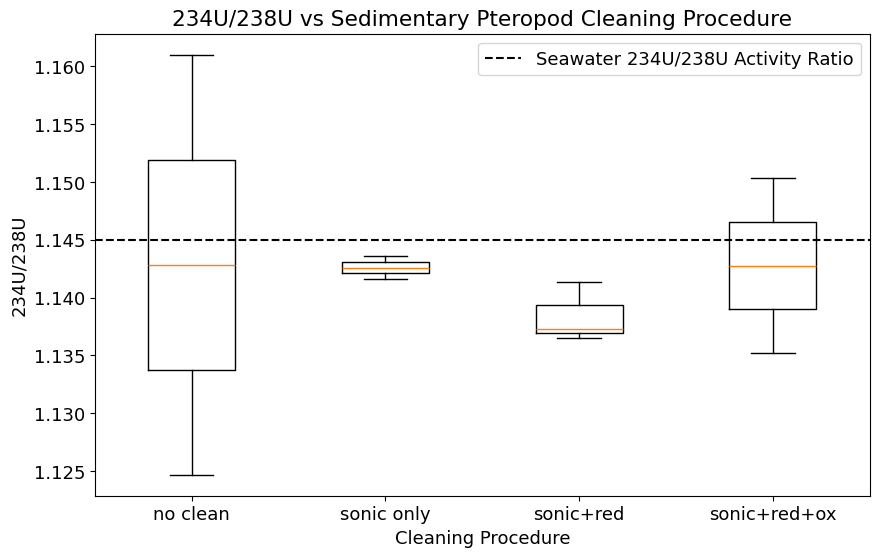

In [27]:
#graph 3 boxplot sedimentary pteropods columns 234U/238U mols vs cleaning procedure



# getting U nmols/ Ca mols from each cleaning type 
noclean234U_238U = noclean['[234U]/[238U]']
sonic234U_238U = sonic['[234U]/[238U]']
redsonic234U_238U = redsonic['[234U]/[238U]']
oxredsonic234U_238U = oxredsonic['[234U]/[238U]']

#combining data
cleantype = noclean234U_238U, sonic234U_238U, redsonic234U_238U, oxredsonic234U_238U
cleaning = {
    'no clean' : nocleanU,
    'sonic only': sonicU,
    'sonic+red' : redsonicU,
    'sonic+red+ox' : oxredsonicU
}
#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantype, tick_labels=cleaning)



#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('234U/238U')

#plot title
plt.title('234U/238U vs Sedimentary Pteropod Cleaning Procedure')

print(sum(redsonic234U_238U)/len(redsonic234U_238U))

print(sum(oxredsonic234U_238U)/len(oxredsonic234U_238U))

plt.axhline(y=1.145, color='black', linestyle='--', linewidth=1.5, label='Seawater 234U/238U Activity Ratio')
plt.legend()

4    1.137331
5    1.141331
6    1.136548
Name: [234U]/[238U], dtype: float64
7    1.150363
8    1.135191
Name: [234U]/[238U], dtype: float64


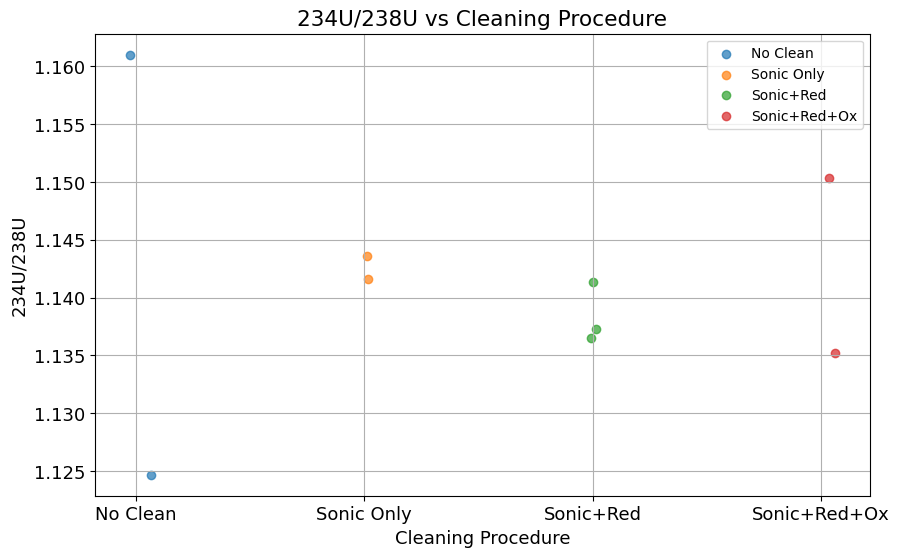

In [32]:
#graph 4 bar plots sedimentary pteropods columns 234U/238U mols vs cleaning procedure

# getting U nmols/ Ca mols from each cleaning type 
noclean234U_238U = noclean['[234U]/[238U]']
sonic234U_238U = sonic['[234U]/[238U]']
redsonic234U_238U = redsonic['[234U]/[238U]']
oxredsonic234U_238U = oxredsonic['[234U]/[238U]']
print(redsonic234U_238U)
print(oxredsonic234U_238U)
#combining data
cleantype = [noclean234U_238U, sonic234U_238U, redsonic234U_238U, oxredsonic234U_238U]
cleaning = ['No Clean','Sonic Only','Sonic+Red','Sonic+Red+Ox']

#create figure
plt.figure(figsize=(10, 6))

#create scatterplot
#enumerate allows for cleantypes to be numbered to be able to scatter plot
for i, values in enumerate(cleantype):
    x = np.random.normal(i+1, 0.04, size=len(values))  # so points don’t overlap on x axis 
    plt.scatter(x, values, alpha=0.7)

#replace numbers with category labels
plt.xticks(range(1, len(cleaning)+1), cleaning)


#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('234U/238U')

#plot title
plt.title('234U/238U vs Cleaning Procedure')

#plot legend
plt.legend(cleaning, fontsize = 10)

#add grid lines
plt.grid()

In [ ]:
#graph 5: d234U per mille

#graph 3 boxplot sedimentary pteropods columns 234U/238U mols vs cleaning procedure



# getting U nmols/ Ca mols from each cleaning type 
noclean234U_238U = noclean['[234U]/[238U]']
sonic234U_238U = sonic['[234U]/[238U]']
redsonic234U_238U = redsonic['[234U]/[238U]']
oxredsonic234U_238U = oxredsonic['[234U]/[238U]']

noclean234U = (noclean234U_238U - 1)*1000
sonic234U = (sonic234U_238U - 1)*1000
redsonic234U = (redsonic234U_238U - 1)*1000
oxredsonic234U = (oxredsonic234U_238U - 1)*1000

#combining data
cleantype = noclean234U, sonic234U, redsonic234U, oxredsonic234U
cleaning = {'no clean' : nocleanU,'sonic only': sonicU, 'sonic+red' : redsonicU,'sonic+red+ox' : oxredsonicU}

#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantype, tick_labels=cleaning, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))



#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('234U per mille')

#plot title
plt.title('234U per mille vs Cleaning Procedure')

#add grid lines
plt.grid()

print(sum(redsonic234U)/len(redsonic234U))

print(sum(oxredsonic234U)/len(oxredsonic234U))

print(redsonic234U)


